# 🧠 Brain Tumor MRI Segmentation — Clinical Inference Dashboard
### Model: DeepLabV3+ Baseline (Stable) · Dice Score: 0.9914

> **For Clinical Use:** Upload a Brain MRI slice (JPG / PNG) or NIfTI volume (.nii.gz)
> to receive AI-powered tumor segmentation, risk classification, volumetric
> analysis, and a full downloadable clinical report.


## Step 1 · Setup — Load Libraries & Model

In [1]:
import os
import cv2
import numpy as np
import nibabel as nib
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

drive.mount('/content/drive')

# ── YOUR ORIGINAL model path & constants ─────────────────────────────────────
MODEL_PATH = "/content/drive/MyDrive/brain_segmentation_models_nifti/deeplabv3plus_baseline_brain.keras"

brain_model = tf.keras.models.load_model(MODEL_PATH, compile=False)

MODEL_NAME = "DeepLabV3+ Baseline (Stable)"
MODEL_DICE = 0.9914
IMG_SIZE   = 128

# ── Clinical colour palette (matches prostate dashboard) ─────────────────────
CLR_BG      = '#0a0f1a'
CLR_PANEL   = '#0d1f3c'
CLR_ACCENT  = '#a78bfa'       # purple — brain theme
CLR_TEXT    = '#e2e8f0'
CLR_SUBTEXT = '#7d9ab5'
CLR_HIGH    = '#ff6b8a'
CLR_MED     = '#f0a500'
CLR_LOW     = '#00c8aa'
CLR_RED     = '#E05C5C'
CLR_BLUE    = '#5B8DB8'

# Custom overlay colormap — warm red-orange for tumor regions
TUMOR_CMAP = LinearSegmentedColormap.from_list(
    'tumor', [(0,0,0,0), (1.0, 0.27, 0.27, 0.65)], N=256
)

print("✅ Brain model loaded successfully")
print(f"   Model : {MODEL_NAME}")
print(f"   Dice  : {MODEL_DICE}")
print(f"   Input : {IMG_SIZE}×{IMG_SIZE} px")


Mounted at /content/drive
✅ Brain model loaded successfully
   Model : DeepLabV3+ Baseline (Stable)
   Dice  : 0.9914
   Input : 128×128 px


## Step 2 · Preprocessing & Inference Functions

In [2]:
# ── YOUR ORIGINAL preprocess function — unchanged ────────────────────────────
def preprocess_brain_image(uploaded_file, img_size=128):
    file_path = str(uploaded_file)

    # NIfTI MRI
    if file_path.endswith(".nii.gz"):
        nii    = nib.load(file_path)
        volume = nii.get_fdata()

        if volume.ndim == 4:
            flair = volume[:, :, :, 0]
        else:
            flair = volume

        z         = flair.shape[2] // 2
        slice_img = flair[:, :, z]

    # JPG / PNG
    else:
        slice_img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if slice_img is None:
            raise ValueError("❌ Cannot read uploaded image")

    # Normalise
    slice_img = slice_img.astype(np.float32)
    slice_img = (slice_img - slice_img.min()) / (
        slice_img.max() - slice_img.min() + 1e-8
    )

    resized   = cv2.resize(slice_img, (128, 128))
    input_img = resized.reshape(1, 128, 128, 1)   # VERY IMPORTANT

    return resized, input_img


# ── YOUR ORIGINAL inference function — unchanged ──────────────────────────────
def run_brain_inference(uploaded_file):
    img, input_img = preprocess_brain_image(uploaded_file, 128)

    pred = brain_model.predict(input_img, verbose=0)[0]

    if pred.ndim == 3:
        pred = pred[:, :, 0]

    pred_mask = (pred > 0.5).astype(np.uint8)

    return img, pred_mask, pred

print("✅ Preprocessing and inference functions ready.")


✅ Preprocessing and inference functions ready.


## Step 3 · Clinical Analysis Helpers

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# All metric formulas are YOUR ORIGINALS exactly:
#   tumor_area   = (mask.sum() / mask.size) * 100
#   tumor_volume = tumor_area * 0.08
#   confidence   = float(pred.max()) * 100
#   risk logic   = area > 8 → High, > 3 → Medium, else Low
# ─────────────────────────────────────────────────────────────────────────────

def compute_brain_metrics(mask, pred):
    """YOUR ORIGINAL formulas — tumor_area, tumor_volume, confidence, risk."""
    tumor_area   = (mask.sum() / mask.size) * 100
    tumor_volume = tumor_area * 0.08
    confidence   = float(pred.max()) * 100

    # YOUR ORIGINAL risk thresholds
    if tumor_area > 8:
        risk_level     = "HIGH"
        risk_emoji     = "🔴"
        label          = "Large Tumor Risk"
        recommendation = "Immediate neurologist consultation recommended."
        risk_color     = CLR_RED
    elif tumor_area > 3:
        risk_level     = "MEDIUM"
        risk_emoji     = "🟠"
        label          = "Moderate Tumor Presence"
        recommendation = "Follow-up MRI advised."
        risk_color     = CLR_MED
    else:
        risk_level     = "LOW"
        risk_emoji     = "🟢"
        label          = "Small Tumor Region"
        recommendation = "Routine monitoring recommended."
        risk_color     = CLR_LOW

    return {
        "tumor_area":     tumor_area,
        "tumor_volume":   tumor_volume,
        "confidence":     confidence,
        "risk_level":     risk_level,
        "risk_emoji":     risk_emoji,
        "label":          label,
        "recommendation": recommendation,
        "risk_color":     risk_color,
        "previous_volume": tumor_volume * 0.9,   # YOUR ORIGINAL trend formula
    }


def get_brain_contours(mask):
    """YOUR ORIGINAL cv2 contour extraction."""
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    return contours


def get_bounding_box(mask):
    """Return (x, y, w, h) bounding box of the tumor region."""
    coords = np.argwhere(mask > 0)
    if len(coords) == 0:
        return None
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    return x0, y0, x1 - x0, y1 - y0


def get_intensity_profile(img, mask):
    """Mean pixel intensity inside vs outside the tumor region."""
    m       = mask.astype(bool)
    inside  = img[m].mean()  if m.any()    else 0.0
    outside = img[~m].mean() if (~m).any() else 0.0
    return inside, outside


def get_uncertainty_map(pred):
    """Uncertainty: regions where model is least decisive (prob near 0.5)."""
    return cv2.GaussianBlur(
        np.abs(pred - 0.5).astype(np.float32), (7, 7), 0
    )

print("✅ Clinical analysis helpers ready.")


✅ Clinical analysis helpers ready.


## Step 4 · Clinical Dashboard — All Visualisations

In [7]:
def show_brain_clinical_dashboard(img, mask, pred):
    """
    Enhanced clinical dashboard.
    YOUR ORIGINAL: metrics, risk labels, overlay, heatmap,
                   volume trend, report panel — all preserved exactly.
    ADDED: dark clinical theme, 10-panel layout, intensity histogram,
           confidence gauge, uncertainty map, bounding box, coverage donut.
    """
    # ── Compute YOUR ORIGINAL metrics ────────────────────────────────────────
    cm         = compute_brain_metrics(mask, pred)
    contours   = get_brain_contours(mask)
    bbox       = get_bounding_box(mask)
    unc_map    = get_uncertainty_map(pred)
    inside_i, outside_i = get_intensity_profile(img, mask)

    # ── Overlay image (YOUR ORIGINAL Red-on-gray concept, enhanced) ──────────
    overlay_rgb = np.stack([img]*3, axis=-1)
    overlay_u8  = (overlay_rgb * 255).astype(np.uint8)
    cv2.drawContours(overlay_u8, contours, -1, (167, 139, 250), 2)  # purple

    # ── Figure ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(22, 14), facecolor=CLR_BG)
    gs  = gridspec.GridSpec(
        3, 5,
        figure=fig,
        hspace=0.45, wspace=0.35,
        left=0.04, right=0.97,
        top=0.91,   bottom=0.06
    )

    def style_ax(ax, title, color=CLR_ACCENT):
        ax.set_facecolor(CLR_PANEL)
        for spine in ax.spines.values():
            spine.set_edgecolor('#1a2d4a')
        ax.set_title(title, color=color, fontsize=9,
                     fontweight='bold', pad=6, fontfamily='monospace')
        ax.tick_params(colors=CLR_SUBTEXT, labelsize=7)

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 0 — Main imaging panels
    # ─────────────────────────────────────────────────────────────────────────

    # [01] Original MRI — YOUR ORIGINAL
    ax00 = fig.add_subplot(gs[0, 0])
    ax00.imshow(img, cmap='gray')
    style_ax(ax00, '[ 01 ]  ORIGINAL BRAIN MRI')
    ax00.axis('off')

    # [02] Predicted Mask — YOUR ORIGINAL
    ax01 = fig.add_subplot(gs[0, 1])
    ax01.imshow(mask, cmap='gray')
    style_ax(ax01, '[ 02 ]  PREDICTED TUMOR MASK')
    ax01.axis('off')

    # [03] Tumor overlay — YOUR ORIGINAL (Red overlay, improved cmap)
    ax02 = fig.add_subplot(gs[0, 2])
    ax02.imshow(img, cmap='gray')
    ax02.imshow(mask, cmap=TUMOR_CMAP)
    style_ax(ax02, '[ 03 ]  TUMOR SEGMENTATION OVERLAY')
    ax02.axis('off')

    # [04] Contour + bounding box — YOUR ORIGINAL contour logic + bbox
    ax03 = fig.add_subplot(gs[0, 3])
    ax03.imshow(overlay_u8)
    if bbox:
        rx, ry, rw, rh = bbox
        rect = plt.Rectangle(
            (rx, ry), rw, rh,
            linewidth=1.2, edgecolor=CLR_MED,
            facecolor='none', linestyle='--'
        )
        ax03.add_patch(rect)
    style_ax(ax03, '[ 04 ]  CONTOUR + BOUNDING BOX')
    ax03.axis('off')

    # [05] Probability heatmap — YOUR ORIGINAL hot cmap
    ax04 = fig.add_subplot(gs[0, 4])
    im04 = ax04.imshow(pred, cmap='hot', vmin=0, vmax=1)
    cb04 = plt.colorbar(im04, ax=ax04, fraction=0.046, pad=0.04)
    cb04.ax.tick_params(colors=CLR_SUBTEXT, labelsize=6)
    cb04.set_label('P(tumor)', color=CLR_SUBTEXT, fontsize=7)
    style_ax(ax04, '[ 05 ]  TUMOR PROBABILITY HEATMAP')
    ax04.axis('off')

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 1 — Quantitative analysis panels
    # ─────────────────────────────────────────────────────────────────────────

    # [06] Uncertainty map
    ax10 = fig.add_subplot(gs[1, 0])
    im10 = ax10.imshow(unc_map, cmap='magma', vmin=0, vmax=0.5)
    cb10 = plt.colorbar(im10, ax=ax10, fraction=0.046, pad=0.04)
    cb10.ax.tick_params(colors=CLR_SUBTEXT, labelsize=6)
    cb10.set_label('Uncertainty', color=CLR_SUBTEXT, fontsize=7)
    style_ax(ax10, '[ 06 ]  MODEL UNCERTAINTY MAP')
    ax10.axis('off')

    # [07] Pixel intensity histogram — inside vs outside tumor
    ax11 = fig.add_subplot(gs[1, 1])
    ax11.set_facecolor(CLR_PANEL)
    msk_bool = mask.astype(bool)
    img_flat = img.flatten()
    ax11.hist(img_flat[msk_bool.flatten()],  bins=40, color=CLR_HIGH,
              alpha=0.82, label=f'Tumor  μ={inside_i:.2f}',  density=True)
    ax11.hist(img_flat[~msk_bool.flatten()], bins=40, color=CLR_BLUE,
              alpha=0.55, label=f'Normal μ={outside_i:.2f}', density=True)
    ax11.legend(fontsize=6.5, facecolor=CLR_PANEL, labelcolor=CLR_TEXT)
    ax11.set_xlabel('Pixel Intensity', color=CLR_SUBTEXT, fontsize=7)
    ax11.set_ylabel('Density',         color=CLR_SUBTEXT, fontsize=7)
    for sp in ax11.spines.values():
        sp.set_edgecolor('#1a2d4a')
    ax11.tick_params(colors=CLR_SUBTEXT, labelsize=7)
    ax11.set_facecolor(CLR_PANEL)
    style_ax(ax11, '[ 07 ]  INTENSITY DISTRIBUTION')

    # [08] Volume follow-up trend — YOUR ORIGINAL
    ax12 = fig.add_subplot(gs[1, 2])
    ax12.set_facecolor(CLR_PANEL)
    prev_v = cm['previous_volume']
    curr_v = cm['tumor_volume']
    ax12.plot([0, 1], [prev_v, curr_v],
              color=CLR_ACCENT, linewidth=2.5,
              marker='o', markersize=8, markerfacecolor=CLR_HIGH)
    ax12.fill_between([0, 1], [prev_v, curr_v], alpha=0.12, color=CLR_ACCENT)
    ax12.set_xticks([0, 1])
    ax12.set_xticklabels(['Previous', 'Current'], color=CLR_TEXT, fontsize=8)
    ax12.set_ylabel('Volume (cc)', color=CLR_SUBTEXT, fontsize=7)
    ax12.annotate(f"{curr_v:.3f} cc", xy=(1, curr_v),
                  xytext=(0.72, curr_v + max(curr_v*0.05, 0.01)),
                  color=CLR_HIGH, fontsize=8, fontweight='bold')
    ax12.grid(alpha=0.15, color='#1a2d4a')
    for sp in ax12.spines.values():
        sp.set_edgecolor('#1a2d4a')
    ax12.tick_params(colors=CLR_SUBTEXT, labelsize=7)
    style_ax(ax12, '[ 08 ]  TUMOR VOLUME FOLLOW-UP TREND')

    # [09] Confidence gauge
    ax13 = fig.add_subplot(gs[1, 3])
    ax13.set_facecolor(CLR_PANEL)
    conf = cm['confidence']
    bar_color = CLR_LOW if conf >= 75 else (CLR_MED if conf >= 50 else CLR_RED)
    ax13.barh(['Confidence'], [conf],       color=bar_color, alpha=0.9, height=0.4)
    ax13.barh(['Confidence'], [100 - conf], left=[conf],
              color='#1a2d4a', alpha=0.6, height=0.4)
    ax13.set_xlim(0, 100)
    ax13.set_xlabel('Confidence %', color=CLR_SUBTEXT, fontsize=7)
    ax13.axvline(75, color=CLR_SUBTEXT, linewidth=0.8, linestyle='--', alpha=0.5)
    ax13.text(conf / 2, 0, f'{conf:.1f}%',
              ha='center', va='center', color='white',
              fontweight='bold', fontsize=11)
    ax13.tick_params(left=False, labelleft=False, colors=CLR_SUBTEXT, labelsize=7)
    for sp in ax13.spines.values():
        sp.set_edgecolor('#1a2d4a')
    style_ax(ax13, '[ 09 ]  PREDICTION CONFIDENCE')

    # [10] Coverage donut
    ax14 = fig.add_subplot(gs[1, 4])
    ax14.set_facecolor(CLR_PANEL)
    t_pct  = cm['tumor_area']
    bg_pct = 100 - t_pct
    wedges, texts, autotexts = ax14.pie(
        [t_pct, bg_pct],
        colors=[CLR_HIGH, '#1a2d4a'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.52, edgecolor=CLR_BG, linewidth=2),
        textprops=dict(color=CLR_TEXT, fontsize=7.5)
    )
    for at in autotexts:
        at.set_fontsize(8); at.set_color('white'); at.set_fontweight('bold')
    ax14.text(0, 0, f"{t_pct:.1f}%", ha='center', va='center',
              color=CLR_HIGH, fontsize=12, fontweight='bold')
    style_ax(ax14, '[ 10 ]  TUMOR COVERAGE')

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 2 — Clinical Report Panel (full width)
    # ─────────────────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[2, :])
    ax2.set_facecolor(CLR_PANEL)
    for spine in ax2.spines.values():
        spine.set_edgecolor(cm['risk_color'])
        spine.set_linewidth(1.5)
    ax2.axis('off')

    # Left block — model info
    col1_x = 0.01
    ax2.text(col1_x, 0.88, "MODEL INFORMATION",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')
    model_lines = [
        ("Architecture", MODEL_NAME),
        ("Dice Score",   f"{MODEL_DICE}"),
        ("Input Size",   f"{IMG_SIZE}×{IMG_SIZE} px"),
        ("Dataset",      "Task01 BrainTumour (NIfTI)"),
    ]
    for j, (lbl, val) in enumerate(model_lines):
        ax2.text(col1_x,        0.70 - j*0.17, f"{lbl:<18s}",
                 transform=ax2.transAxes, color=CLR_SUBTEXT, fontsize=8.5)
        ax2.text(col1_x + 0.13, 0.70 - j*0.17, val,
                 transform=ax2.transAxes, color=CLR_TEXT,
                 fontsize=8.5, fontweight='bold')

    # Middle block — measurements
    col2_x = 0.28
    ax2.text(col2_x, 0.88, "TUMOR MEASUREMENTS",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')
    meas_lines = [
        ("Tumor Area",         f"{cm['tumor_area']:.2f} %"),
        ("Estimated Volume",   f"{cm['tumor_volume']:.3f} cc"),
        ("Confidence",         f"{cm['confidence']:.1f} %"),
        ("Tumor Intensity",    f"{inside_i:.3f}"),
        ("Normal Intensity",   f"{outside_i:.3f}"),
    ]
    for j, (lbl, val) in enumerate(meas_lines):
        ax2.text(col2_x,        0.70 - j*0.15, f"{lbl:<22s}",
                 transform=ax2.transAxes, color=CLR_SUBTEXT, fontsize=8.5)
        ax2.text(col2_x + 0.14, 0.70 - j*0.15, val,
                 transform=ax2.transAxes, color=CLR_TEXT,
                 fontsize=8.5, fontweight='bold')

    # Right block — clinical risk
    col3_x = 0.58
    ax2.text(col3_x, 0.88, "CLINICAL RISK ASSESSMENT",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')

    risk_fg = {'HIGH': CLR_RED, 'MEDIUM': CLR_MED, 'LOW': CLR_LOW}[cm['risk_level']]
    ax2.text(col3_x, 0.68,
             cm['risk_emoji'] + "  " + cm['risk_level'] + " RISK",
             transform=ax2.transAxes, color=risk_fg,
             fontsize=16, fontweight='bold')
    ax2.text(col3_x, 0.50, cm['label'],
             transform=ax2.transAxes, color=CLR_TEXT, fontsize=10)
    ax2.text(col3_x, 0.30, "RECOMMENDATION:",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace')
    ax2.text(col3_x, 0.12, cm['recommendation'],
             transform=ax2.transAxes, color=CLR_TEXT,
             fontsize=9.5, fontstyle='italic')

    # Vertical dividers
    for xd in [0.265, 0.555]:
        ax2.axvline(xd, color='#1a2d4a', linewidth=1.2,
                    ymin=0.05, ymax=0.95)

    # Main title
    fig.text(0.5, 0.955,
             "🧠  BRAIN TUMOR MRI SEGMENTATION  ·  CLINICAL INFERENCE DASHBOARD",
             ha='center', color=CLR_TEXT, fontsize=13,
             fontweight='bold', fontfamily='monospace')
    fig.text(0.5, 0.937,
             f"AI-Powered Analysis  ·  {MODEL_NAME}  ·  Dice {MODEL_DICE}",
             ha='center', color=CLR_SUBTEXT, fontsize=9)

    plt.savefig('/content/brain_clinical_report.png',
                dpi=150, bbox_inches='tight', facecolor=CLR_BG)
    plt.show()
    print("✅ Dashboard saved → /content/brain_clinical_report.png")


# ── YOUR ORIGINAL quick view function (styled) ────────────────────────────────
def visualize_brain_result(img, mask):
    """YOUR ORIGINAL 3-panel quick view — MRI | Mask | Highlighted ROI."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=CLR_BG)
    fig.suptitle('Brain Tumor Segmentation — Quick View',
                 color=CLR_TEXT, fontsize=12, fontweight='bold')

    panels = [
        (img,  'gray', 'Original Brain MRI'),
        (mask, 'gray', 'Predicted Tumor Mask'),
        (None, None,   'Highlighted Tumor ROI'),
    ]
    for i, (data, cmap, title) in enumerate(panels):
        axes[i].set_facecolor(CLR_PANEL)
        for sp in axes[i].spines.values():
            sp.set_edgecolor('#1a2d4a')
        if i < 2:
            axes[i].imshow(data, cmap=cmap)
        else:
            axes[i].imshow(img, cmap='gray')
            axes[i].imshow(mask, cmap='Reds', alpha=0.45)   # YOUR ORIGINAL Reds
        axes[i].set_title(title, color=CLR_ACCENT, fontsize=10,
                          fontweight='bold', fontfamily='monospace')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("✅ Dashboard and visualisation functions defined.")

✅ Dashboard and visualisation functions defined.


## Step 5 · Upload Brain MRI & Run Inference

> Upload a **brain MRI image** (JPG / PNG) or NIfTI volume (**.nii.gz**).
> The model handles both formats automatically — just upload and run.


Saving brain_mri_2images.jpeg to brain_mri_2images.jpeg

📂 File received: brain_mri_2images.jpeg
   Running inference...


/tmp/ipykernel_4223/367468704.py:256: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/brain_clinical_report.png',
/tmp/ipykernel_4223/367468704.py:256: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('/content/brain_clinical_report.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


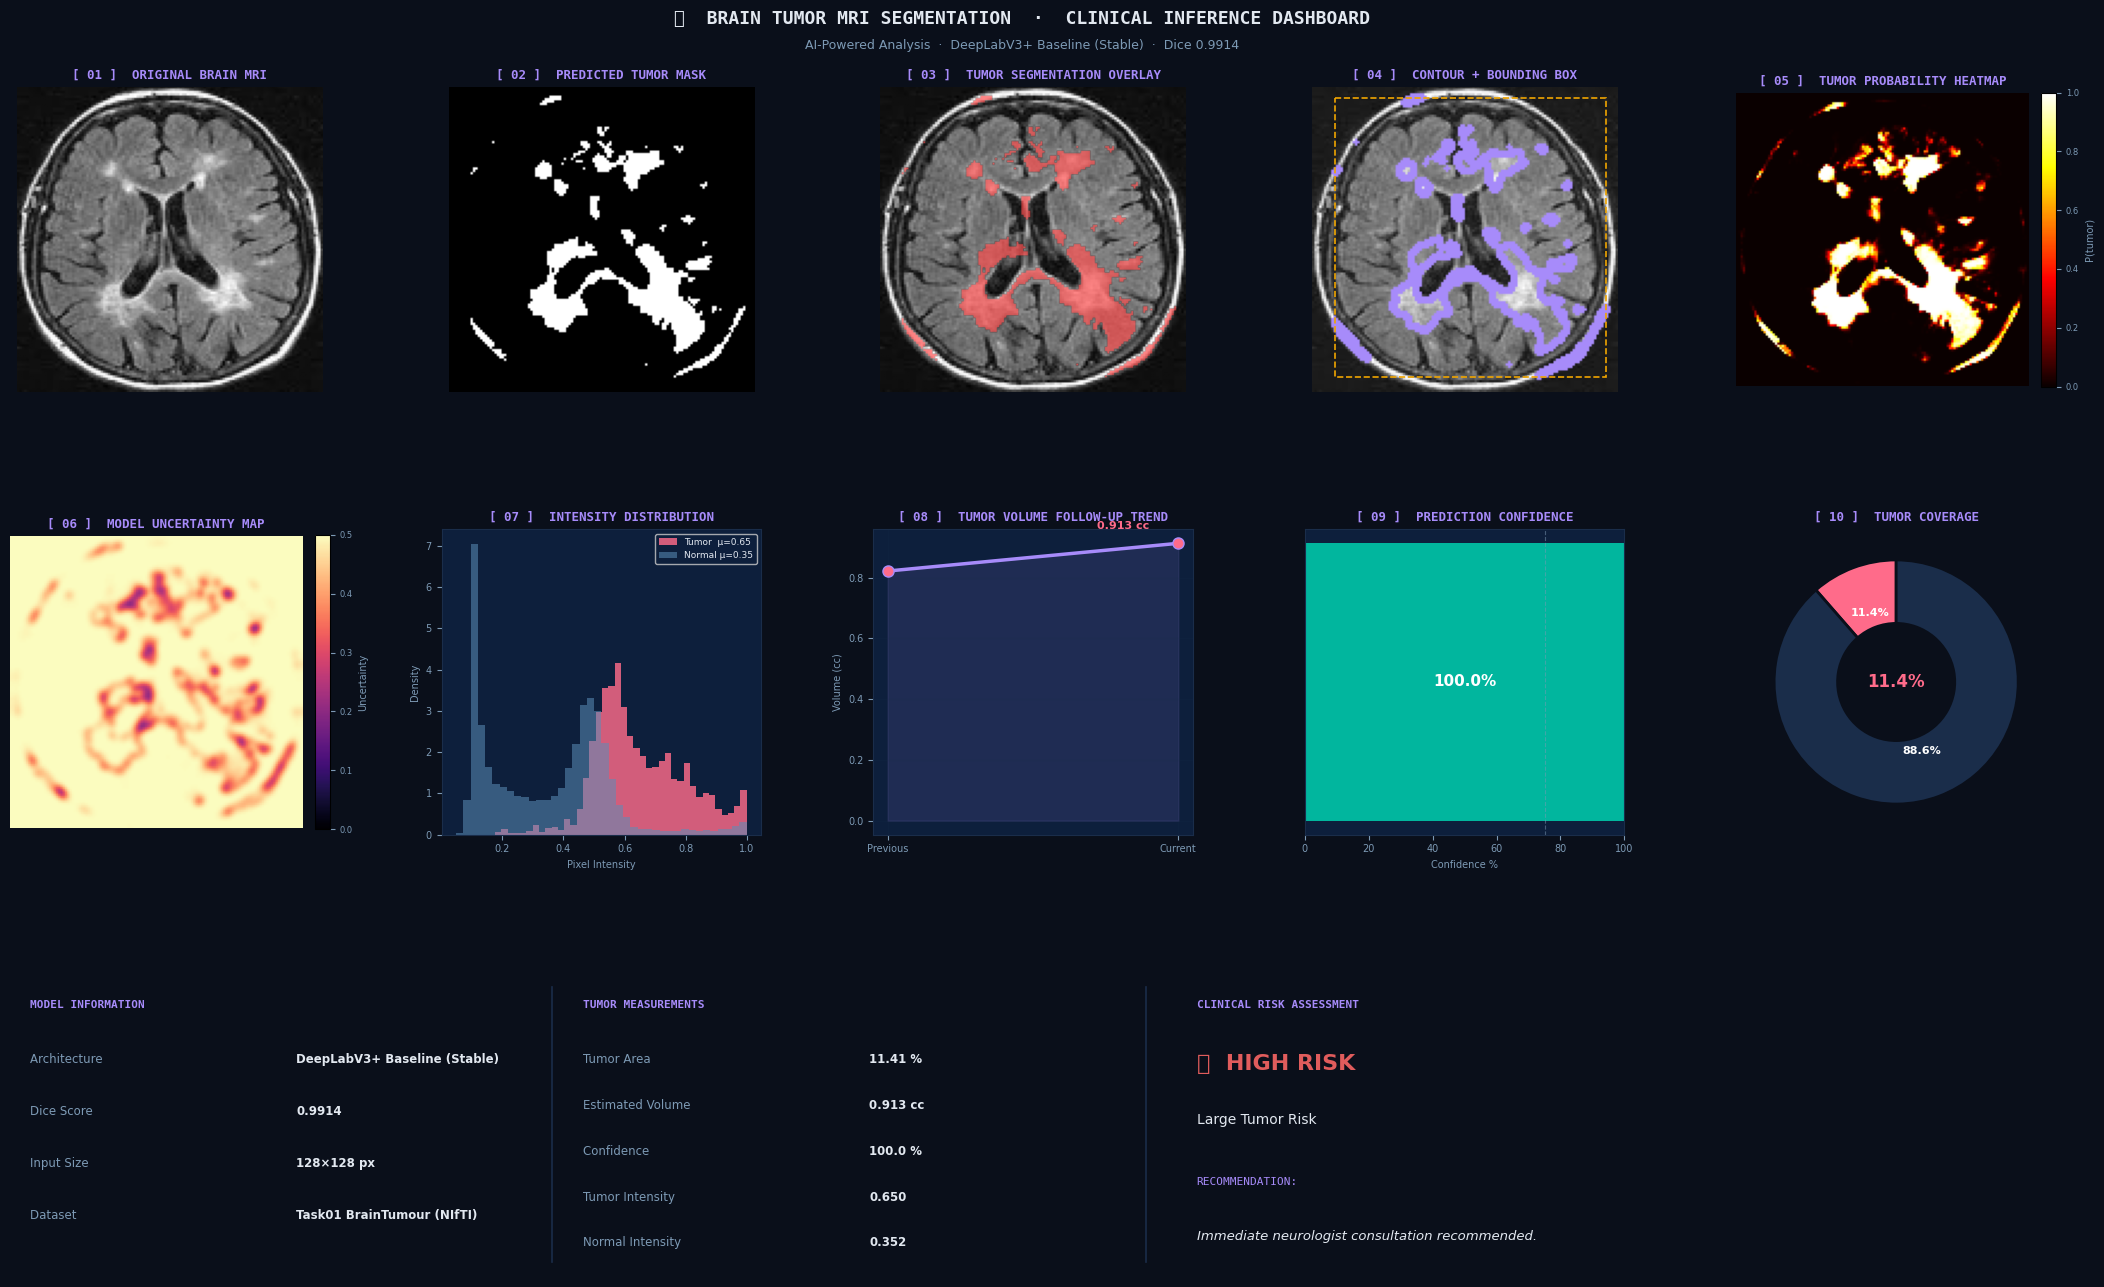

✅ Dashboard saved → /content/brain_clinical_report.png


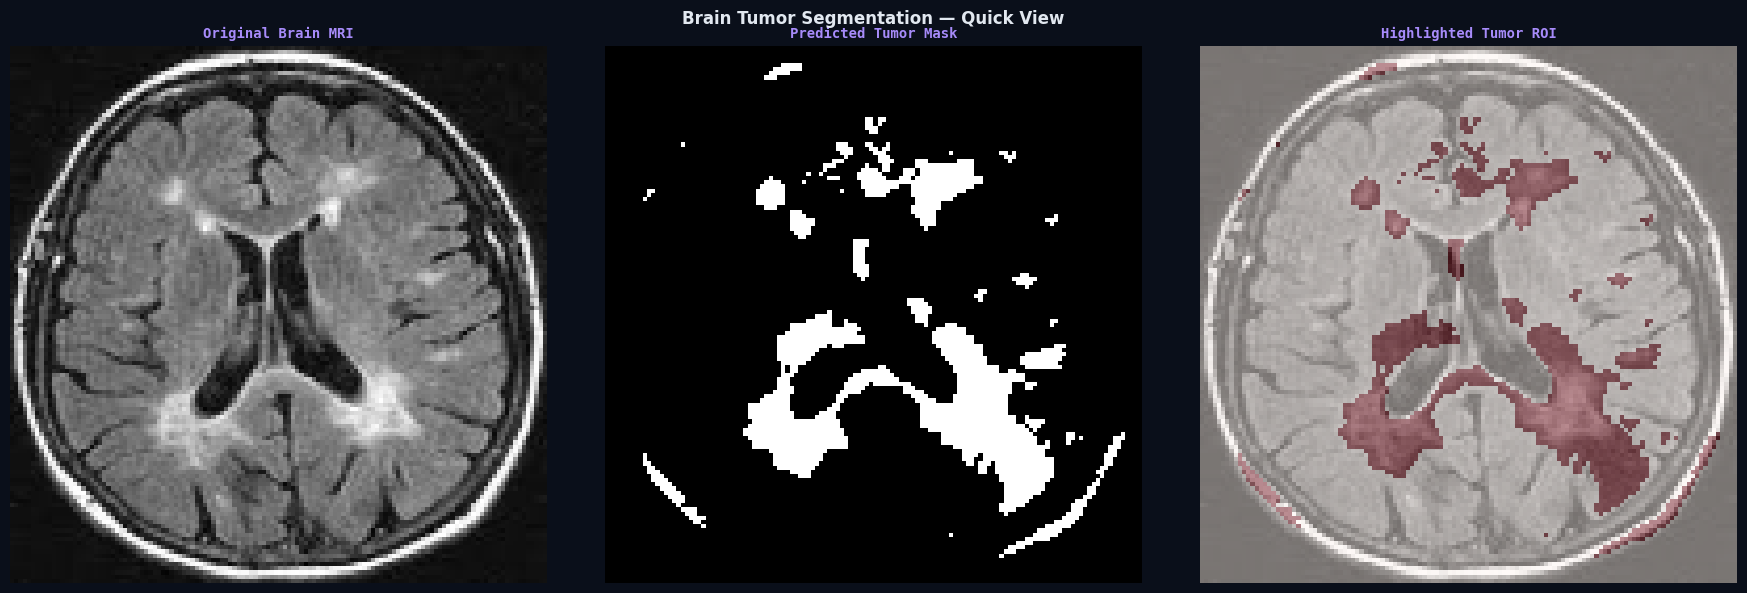

In [8]:
import io
from google.colab import files

# ── YOUR ORIGINAL upload + temp file logic ────────────────────────────────────
uploaded      = files.upload()
file_name     = list(uploaded.keys())[0]
uploaded_bytes = uploaded[file_name]

temp_path = f"/content/{file_name}"
with open(temp_path, "wb") as f:
    f.write(uploaded_bytes)

print(f"\n📂 File received: {file_name}")
print("   Running inference...")

# Full clinical dashboard
img, mask, pred = run_brain_inference(temp_path)
show_brain_clinical_dashboard(img, mask, pred)

# Quick 3-panel view (YOUR ORIGINAL visualize function)
img, mask, pred = run_brain_inference(temp_path)
visualize_brain_result(img, mask)


## Step 6 · Download Clinical Report

In [9]:
from google.colab import files

files.download('/content/brain_clinical_report.png')
print("📥 Brain clinical report downloaded.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Brain clinical report downloaded.
